# Perception Stack - Notebook 00: Data Download and Setup

This notebook downloads and prepares all data required for the Perception Stack pipeline.
It selects 70 CLEVRER validation clips, downloads the raw video files, annotation JSONs,
and extracts the last frame keyframe from each clip for use in all subsequent notebooks.

## Steps
- Mount Google Drive and create the full project folder structure
- Download the CLEVRER validation QA JSON file
- Select the first 70 validation clips (IDs 10001 to 10070)
- Download raw `.mp4` video files for all 70 clips (skip if already present)
- Verify all downloaded clips are readable via OpenCV
- Download annotation JSON files for all 70 clips from the CLEVRER annotation zip
- Inspect annotation file structure (object properties, motion trajectories, collision events)
- Extract the last frame (frame 127) from each clip and save as JPEG keyframes
- Generate summary figures: clip thumbnails and question type distribution bar chart
- Report final Drive storage usage

---
> **Note:** This notebook is natively developed and run on Google Colab.
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/1FiHg-Q6QsNPQrm6mMxpnmsUKJEo8J0sP?usp=sharing>)

Define 'No. of Clips' to work with:

In [1]:
NO_CLIPS = 70  # change this one number to scale up later

---
## Cell 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


- delete previous files

In [3]:
# ── CLEAR: Delete all files generated by NB00 ──────────────────────────────
import os, shutil

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

files_to_delete = [
    os.path.join(BASE, "data/selected_clip_ids.json"),
    os.path.join(BASE, "data/keyframe_index.json"),
]
dirs_to_clear = [
    os.path.join(BASE, "data/keyframes"),
]
figures_to_clear = [f for f in os.listdir(os.path.join(BASE, "figures"))
                    if f.startswith("00_")]

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")

for d in dirs_to_clear:
    if os.path.exists(d):
        shutil.rmtree(d)
        os.makedirs(d)
        print(f"Cleared: {d}")

for f in figures_to_clear:
    path = os.path.join(BASE, "figures", f)
    os.remove(path)
    print(f"Deleted figure: {f}")

print("NB00 slate cleared.")

Deleted: /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/selected_clip_ids.json
Cleared: /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/keyframes
NB00 slate cleared.


---
## Cell 2 — Create Project Folder Structure

Creates all folders under the base path. Safe to rerun — existing folders are not overwritten.

In [4]:
import os

# ── Base path on Drive ─────────────────────────────────────────────────────────
BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# ── Full folder map ────────────────────────────────────────────────────────────
FOLDERS = [
    "data/clips",            # 50 raw .mp4 files (permanent)
    "data/qa",               # CLEVRER QA JSON (permanent)
    "outputs/stage1_sam2",   # centroids, collision frames per clip (.npz)
    "outputs/stage2_depth",  # depth scalars per object per clip (.npz)
    "outputs/stage3_raft",   # velocity vectors per object per clip (.npz)
    "outputs/stage4_llava",  # VLM answers with/without context (.json)
    "figures",               # all saved plots for report and presentation
    "analysis",              # accuracy tables, delta charts, ablation
]

for folder in FOLDERS:
    path = os.path.join(BASE, folder)
    os.makedirs(path, exist_ok=True)
    print(f'  OK  {path}')

print('\nAll folders ready.')

  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/clips
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/qa
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage1_sam2
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage3_raft
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage4_llava
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures
  OK  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/analysis

All folders ready.


---
## Cell 3 — Install Dependencies

In [5]:
# opencv for video verification, requests for HTTP downloads, tqdm for progress bars
!pip install opencv-python-headless requests tqdm --quiet
print('Dependencies ready.')

Dependencies ready.


---
## Cell 4 — Download QA Annotations

The QA JSON covers all 5000 validation clips but is only a few MB.
We save the full file and filter to our 50 clip IDs in later notebooks.

In [6]:
import requests

# Official CLEVRER QA file hosted by MIT CSAIL
QA_URL = "http://data.csail.mit.edu/clevrer/questions/validation.json"

QA_PATH = os.path.join(BASE, "data/qa/validation_qa.json")

if os.path.exists(QA_PATH):
    print(f'QA file already exists, skipping.\n  {QA_PATH}')
else:
    print('Downloading QA annotations...')
    r = requests.get(QA_URL, stream=True)
    r.raise_for_status()
    with open(QA_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    size_mb = os.path.getsize(QA_PATH) / 1e6
    print(f'Saved ({size_mb:.1f} MB) -> {QA_PATH}')

QA file already exists, skipping.
  /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/qa/validation_qa.json


In [7]:
# ── Cell 4a — Explore Full QA JSON Structure ──────────────────────────────────

# Recursively inspect the JSON structure: all fields, subfields, and sample values.
# Goal: understand the data shape completely before building any logic on top of it.

import json

with open(QA_PATH, 'r') as f:
    all_qa = json.load(f)

# ── Top level ──────────────────────────────────────────────────────────────────
print(f"Top-level type  : {type(all_qa)}")
print(f"Total entries   : {len(all_qa)}")
print(f"Type of entry 0 : {type(all_qa[0])}")
print(f"\nTop-level keys in one entry:")
for key in all_qa[0].keys():
    print(f"  '{key}' : {type(all_qa[0][key]).__name__} = {repr(all_qa[0][key])[:80]}")

# ── Questions field ────────────────────────────────────────────────────────────
print("\n" + "─" * 65)
print("QUESTIONS field — structure of one question object:")
sample_questions = all_qa[0].get('questions', [])
print(f"  Number of questions in clip 0 : {len(sample_questions)}")

if sample_questions:
    q0 = sample_questions[0]
    print(f"\n  Keys in a question object:")
    for key in q0.keys():
        print(f"    '{key}' : {type(q0[key]).__name__} = {repr(q0[key])[:80]}")

# ── Choices field (inside a question) ─────────────────────────────────────────
print("\n" + "─" * 65)
print("CHOICES field — structure of one choice object:")
choices = q0.get('choices', [])
if choices:
    print(f"  Number of choices in question 0 : {len(choices)}")
    print(f"\n  Keys in a choice object:")
    for key in choices[0].keys():
        print(f"    '{key}' : {type(choices[0][key]).__name__} = {repr(choices[0][key])[:80]}")
    print(f"\n  All choices for question 0:")
    for c in choices:
        print(f"    {c}")
else:
    print("  No choices field — direct answer instead:")
    print(f"    answer = {repr(q0.get('answer', 'N/A'))}")

# ── One full example per question type ────────────────────────────────────────
print("\n" + "─" * 65)
print("ONE FULL EXAMPLE PER QUESTION TYPE:\n")

Q_TYPES = ['descriptive', 'explanatory', 'predictive', 'counterfactual']
seen = {t: False for t in Q_TYPES}

for entry in all_qa:
    for q in entry.get('questions', []):
        qt = q.get('question_type')
        if qt in seen and not seen[qt]:
            print(f"  [{qt.upper()}]")
            for key, val in q.items():
                print(f"    {key} : {repr(val)[:120]}")
            print()
            seen[qt] = True
    if all(seen.values()):
        break

# ── Answer format summary ──────────────────────────────────────────────────────
print("─" * 65)
print("ANSWER FORMAT SUMMARY — how answers are stored per type:\n")

format_seen = {t: False for t in Q_TYPES}
for entry in all_qa:
    for q in entry.get('questions', []):
        qt = q.get('question_type')
        if qt in format_seen and not format_seen[qt]:
            has_choices = 'choices' in q and len(q['choices']) > 0
            has_answer  = 'answer' in q
            print(f"  {qt:>15} : ", end='')
            if has_choices:
                correct = [c for c in q['choices'] if c.get('answer') == 'correct']
                print(f"choices field | {len(q['choices'])} options | {len(correct)} correct")
            elif has_answer:
                print(f"direct answer field = {repr(q['answer'])}")
            else:
                print("no answer field found")
            format_seen[qt] = True
    if all(format_seen.values()):
        break

Top-level type  : <class 'list'>
Total entries   : 5000
Type of entry 0 : <class 'dict'>

Top-level keys in one entry:
  'questions' : list = [{'question_id': 0, 'question': 'Are there any stationary green objects when the
  'scene_index' : int = 10000
  'video_filename' : str = 'video_10000.mp4'

─────────────────────────────────────────────────────────────────
QUESTIONS field — structure of one question object:
  Number of questions in clip 0 : 16

  Keys in a question object:
    'question_id' : int = 0
    'question' : str = 'Are there any stationary green objects when the video ends?'
    'question_type' : str = 'descriptive'
    'question_subtype' : str = 'exist'
    'program' : list = ['objects', 'green', 'filter_color', 'end', 'get_frame', 'filter_stationary', 'e
    'answer' : str = 'no'

─────────────────────────────────────────────────────────────────
CHOICES field — structure of one choice object:
  No choices field — direct answer instead:
    answer = 'no'

──────────────

In [8]:
sample_choice_q = next(
    q for entry in all_qa
    for q in entry['questions']
    if q.get('question_type') == 'explanatory'
)
print(sample_choice_q['choices'])

[{'choice_id': 0, 'choice': "the yellow object's entrance", 'program': ['events', 'objects', 'yellow', 'filter_color', 'unique', 'filter_in', 'unique'], 'answer': 'correct'}, {'choice_id': 1, 'choice': 'the presence of the gray sphere', 'program': ['objects', 'gray', 'filter_color', 'sphere', 'filter_shape', 'unique'], 'answer': 'correct'}, {'choice_id': 2, 'choice': "the cylinder's colliding with the sphere", 'program': ['events', 'objects', 'cylinder', 'filter_shape', 'unique', 'filter_collision', 'objects', 'sphere', 'filter_shape', 'unique', 'filter_collision', 'unique'], 'answer': 'correct'}]


In [9]:
# ── Cell 4b — Inspect Sample QA Entries ───────────────────────────────────────

# Load the QA JSON and display all question types for 3 sample clips.
# This is a sanity check -- verify the structure before we build on it.

import json
from pprint import pprint

with open(QA_PATH, 'r') as f:
    all_qa = json.load(f)

# Pick first 3 entries from the JSON for inspection
sample_entries = all_qa[:3]

Q_TYPES = ['descriptive', 'explanatory', 'predictive', 'counterfactual']

for entry in sample_entries:
    clip_id = entry['scene_index']
    questions = entry.get('questions', [])

    print('=' * 65)
    print(f"  CLIP ID : {clip_id}")
    print(f"  Total Q : {len(questions)}")
    print('=' * 65)

    # Group questions by type and print each
    for qtype in Q_TYPES:
        qs = [q for q in questions if q.get('question_type') == qtype]
        if not qs:
            continue
        print(f"\n  [{qtype.upper()}]")
        for q in qs:
            print(f"    Q : {q.get('question', 'N/A')}")

            # Answers vary by question type:
            # - descriptive/predictive: 'choices' list with a correct flag
            # - explanatory/counterfactual: same, but multi-select sometimes
            choices = q.get('choices', [])
            if choices:
                for c in choices:
                    correct = '✓' if c.get('answer') == 'correct' else '✗'
                    print(f"      [{correct}] {c.get('choice', '')}")
            else:
                print(f"      A : {q.get('answer', 'N/A')}")

    print()

  CLIP ID : 10000
  Total Q : 16

  [DESCRIPTIVE]
    Q : Are there any stationary green objects when the video ends?
      A : no
    Q : How many objects are stationary when the yellow object enters the scene?
      A : 0
    Q : How many objects are moving when the video ends?
      A : 3
    Q : What material is the last object that enters the scene?
      A : metal
    Q : What is the shape of the object to collide with the metal sphere?
      A : cylinder
    Q : What material is the object to collide with the sphere?
      A : rubber
    Q : What is the shape of the object that is stationary when the video begins?
      A : cylinder
    Q : What is the shape of the stationary object when the brown cube enters the scene?
      A : cylinder
    Q : Are there any yellow objects that enter the scene?
      A : yes
    Q : How many cylinders enter the scene?
      A : 0
    Q : How many metal objects enter the scene?
      A : 2

  [EXPLANATORY]
    Q : Which of the following is not 

- all questions look multi-answered except 2 types; let's once confirm if all the 'Descriptive' and 'Predictive' are single answer or multi answer

In [10]:
# ── Confirm answer format for Descriptive and Predictive across all 5000 clips ──

stats = {
    'descriptive'  : {'direct': 0, 'choices': 0, 'multi_correct': 0},
    'predictive'   : {'direct': 0, 'choices': 0, 'multi_correct': 0},
}

for entry in all_qa:
    for q in entry.get('questions', []):
        qt = q.get('question_type')
        if qt not in stats:
            continue
        choices = q.get('choices', [])
        if not choices:
            stats[qt]['direct'] += 1
        else:
            stats[qt]['choices'] += 1
            n_correct = sum(1 for c in choices if c.get('answer') == 'correct')
            if n_correct > 1:
                stats[qt]['multi_correct'] += 1

for qt, s in stats.items():
    print(f"\n[{qt.upper()}]")
    print(f"  Direct answer (no choices) : {s['direct']}")
    print(f"  Has choices                : {s['choices']}")
    print(f"  Of those, multi-correct    : {s['multi_correct']}")


[DESCRIPTIVE]
  Direct answer (no choices) : 54990
  Has choices                : 0
  Of those, multi-correct    : 0

[PREDICTIVE]
  Direct answer (no choices) : 0
  Has choices                : 3557
  Of those, multi-correct    : 0


- Descriptive: Always a direct string answer, never choices, never multi-select.
- Predictive: Always choices, never multi-correct -- strictly single-select.

In [11]:
# Defensive check -- warn if any predictive question has multiple correct answers
n_correct = sum(1 for c in choices if c.get('answer') == 'correct')
if n_correct > 1:
    print(f"WARNING: Predictive question {q['question_id']} has {n_correct} correct answers -- check scoring")

^ no print = confirms predictive is always single-select.

In [12]:
# Verify actual scene_index range in the validation QA JSON
indices = [entry['scene_index'] for entry in all_qa]
print(f"Total entries : {len(indices)}")
print(f"Min index     : {min(indices)}")
print(f"Max index     : {max(indices)}")
print(f"All contiguous: {sorted(indices) == list(range(min(indices), max(indices)+1))}")

Total entries : 5000
Min index     : 10000
Max index     : 14999
All contiguous: True


---
## Cell 5 — Select 'n' Clips (seed=42)

CLEVRER validation clips are numbered 10001 to 15000.
We pick 'n' at random with a fixed seed so every notebook uses the exact same set.

--> Be careful about over-writing in this cell!!  It regenerates and overwrites selected_clip_ids.json. But since seed=42 is fixed, it will produce the exact same 'n' IDs every time, so no actual harm. <--

In [13]:
import random
import json

# NO_CLIPS defined here -- change this one number to scale
NO_CLIPS = 70

ALL_VAL_IDS  = list(range(10001, 15001))
SELECTED_IDS = ALL_VAL_IDS[:NO_CLIPS]  # first 70: 10001 to 10070

# Save selected IDs to Drive — all later notebooks load this file
ID_PATH = os.path.join(BASE, "data/selected_clip_ids.json")
with open(ID_PATH, 'w') as f:
    json.dump(SELECTED_IDS, f)

print(f'Selected 50 clip IDs saved to {ID_PATH}')
print(SELECTED_IDS)

Selected 50 clip IDs saved to /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/selected_clip_ids.json
[10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009, 10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045, 10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054, 10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063, 10064, 10065, 10066, 10067, 10068, 10069, 10070]


---
## Cell 6 — Download Clips

Fetches each clip from MIT's CLEVRER server.
Already-downloaded clips are skipped automatically — safe to rerun after a disconnect.

In [14]:
# ── Cell 6 — Download 'n' Clips ────────────────────────────────────────────────

# The full validation set is distributed as one zip (~4GB).
# Strategy:
#   1. Download zip to Colab scratch space (/content/) -- not Drive
#   2. Extract only our 'n' clips directly to Drive
#   3. Delete the zip from scratch space immediately after
# Rerun-safe: skips clips already on Drive.

import os
import json
import zipfile
from tqdm import tqdm

CLIPS_DIR = os.path.join(BASE, "data/clips")
ZIP_LOCAL = "/content/video_validation.zip"

# Load our 'n'' selected IDs
with open(os.path.join(BASE, "data/selected_clip_ids.json"), 'r') as f:
    SELECTED_IDS = json.load(f)

# Check how many clips are already on Drive
already_done = [
    vid_id for vid_id in SELECTED_IDS
    if os.path.exists(os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4"))
    and os.path.getsize(os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")) > 10_000
]

print(f"Already on Drive : {len(already_done)}/{NO_CLIPS}")
print(f"Still needed     : {NO_CLIPS - len(already_done)}/{NO_CLIPS}")

if len(already_done) == NO_CLIPS:
    print("All clips already downloaded. Skipping.")
else:
    # Step 1 — Download zip to scratch space
    print("\nStep 1: Downloading validation zip (~4GB) to Colab scratch...")
    print("This will take 10-20 minutes depending on connection speed.")
    !wget -q --show-progress -O {ZIP_LOCAL} \
        "http://data.csail.mit.edu/clevrer/videos/validation/video_validation.zip"

    # Step 2 — Extract only our 'n' clips to Drive
    print("\nStep 2: Extracting {} clips to Drive...".format(NO_CLIPS))
    needed = set(f"video_{vid_id:05d}.mp4" for vid_id in SELECTED_IDS
                 if vid_id not in already_done)

    with zipfile.ZipFile(ZIP_LOCAL, 'r') as zf:
        all_files = zf.namelist()
        for zip_entry in tqdm(all_files, desc="Scanning zip"):
            filename = os.path.basename(zip_entry)
            if filename in needed:
                data     = zf.read(zip_entry)
                out_path = os.path.join(CLIPS_DIR, filename)
                with open(out_path, 'wb') as f:
                    f.write(data)
                needed.discard(filename)
            if not needed:
                break  # all 'n'' found, stop scanning

    # Step 3 — Delete zip from scratch space
    print("\nStep 3: Deleting zip from scratch space...")
    os.remove(ZIP_LOCAL)
    print("Done. Zip deleted.")

    if needed:
        print(f"\nWARNING: These clips were not found in the zip: {needed}")
    else:
        print("All {} clips extracted successfully.".format(NO_CLIPS))

Already on Drive : 0/70
Still needed     : 70/70

Step 1: Downloading validation zip (~4GB) to Colab scratch...
This will take 10-20 minutes depending on connection speed.
/content/video_vali 100%[===================>]   5.78G  68.6MB/s    in 87s     

Step 2: Extracting 70 clips to Drive...


Scanning zip:  20%|█▉        | 998/5005 [00:01<00:04, 917.51it/s] 



Step 3: Deleting zip from scratch space...
Done. Zip deleted.
All 70 clips extracted successfully.


---
## Cell 7 — Verify Clips & Print Summary Cards

For each clip we confirm:
- File exists on Drive and is readable by OpenCV
- Frame count and FPS match expected values (~128 frames at 25fps)
- QA annotations exist for this clip
- Breakdown of question types (descriptive / explanatory / predictive / counterfactual)

In [15]:
import cv2

# Load and index the QA JSON by scene_index for fast lookup
with open(QA_PATH, 'r') as f:
    all_qa = json.load(f)
qa_by_id = {entry['scene_index']: entry for entry in all_qa}

Q_TYPES = ['descriptive', 'explanatory', 'predictive', 'counterfactual']
summary_rows = []

for vid_id in SELECTED_IDS:
    clip_path = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")

    # ── Video check ──────────────────────────────────────────────────────────
    cap         = cv2.VideoCapture(clip_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps         = cap.get(cv2.CAP_PROP_FPS)
    duration = frame_count / fps if fps > 0 else 0
    readable    = cap.isOpened()
    cap.release()

    # ── QA check ─────────────────────────────────────────────────────────────
    qa_entry    = qa_by_id.get(vid_id, {})
    questions   = qa_entry.get('questions', [])
    type_counts = {t: 0 for t in Q_TYPES}
    for q in questions:
        qt = q.get('question_type', 'unknown')
        if qt in type_counts:
            type_counts[qt] += 1

    summary_rows.append({
        'id': vid_id, 'frames': frame_count, 'fps': fps, 'duration': duration,
        'readable': readable, 'total_q': len(questions), **type_counts
    })

# ── Print summary table ────────────────────────────────────────────────────────
header = f"{'ID':>7} {'Frames':>7} {'FPS':>5} {'Dur(s)':>7} {'Total Q':>8} {'Desc':>5} {'Expl':>5} {'Pred':>5} {'Cf':>5} {'OK':>4}"
print(header)
print('-' * len(header))
for r in summary_rows:
    ok = 'YES' if r['readable'] and r['frames'] > 0 else 'NO'
    print(f"{r['id']:>7} {r['frames']:>7} {r['fps']:>5.1f} {r['duration']:>7.1f} {r['total_q']:>8} "
      f"{r['descriptive']:>5} {r['explanatory']:>5} {r['predictive']:>5} {r['counterfactual']:>5} {ok:>4}")

# ── Totals ────────────────────────────────────────────────────────────────────
print(f"── Question totals across {NO_CLIPS} clips ──")
for t in Q_TYPES:
    print(f'  {t:>15}: {sum(r[t] for r in summary_rows)}')

     ID  Frames   FPS  Dur(s)  Total Q  Desc  Expl  Pred    Cf   OK
-------------------------------------------------------------------
  10001     128  25.0     5.1       16    11     2     1     2  YES
  10002     128  25.0     5.1       15    11     2     0     2  YES
  10003     128  25.0     5.1       16    11     2     1     2  YES
  10004     128  25.0     5.1       15    11     2     0     2  YES
  10005     128  25.0     5.1       15    11     1     1     2  YES
  10006     128  25.0     5.1       15    11     1     1     2  YES
  10007     128  25.0     5.1       15    11     1     1     2  YES
  10008     128  25.0     5.1       16    11     2     1     2  YES
  10009     128  25.0     5.1       15    11     2     1     1  YES
  10010     128  25.0     5.1       15    11     2     0     2  YES
  10011     128  25.0     5.1       16    11     2     1     2  YES
  10012     128  25.0     5.1       15    11     1     1     2  YES
  10013     128  25.0     5.1       15    11    

^^
- Frames -- total number of frames in the clip (all 128, as expected).
- FPS -- frames per second (all 25, as expected).
- OK -- confirms the clip file is readable by OpenCV and has frames > 0.

---
## Cell 8 — Thumbnail Grid (Report Figure)

5 equidistant frames from the first 5 clips — quick visual sanity check.
Saved to `figures/00_clip_thumbnails.jpg` for use in the report.

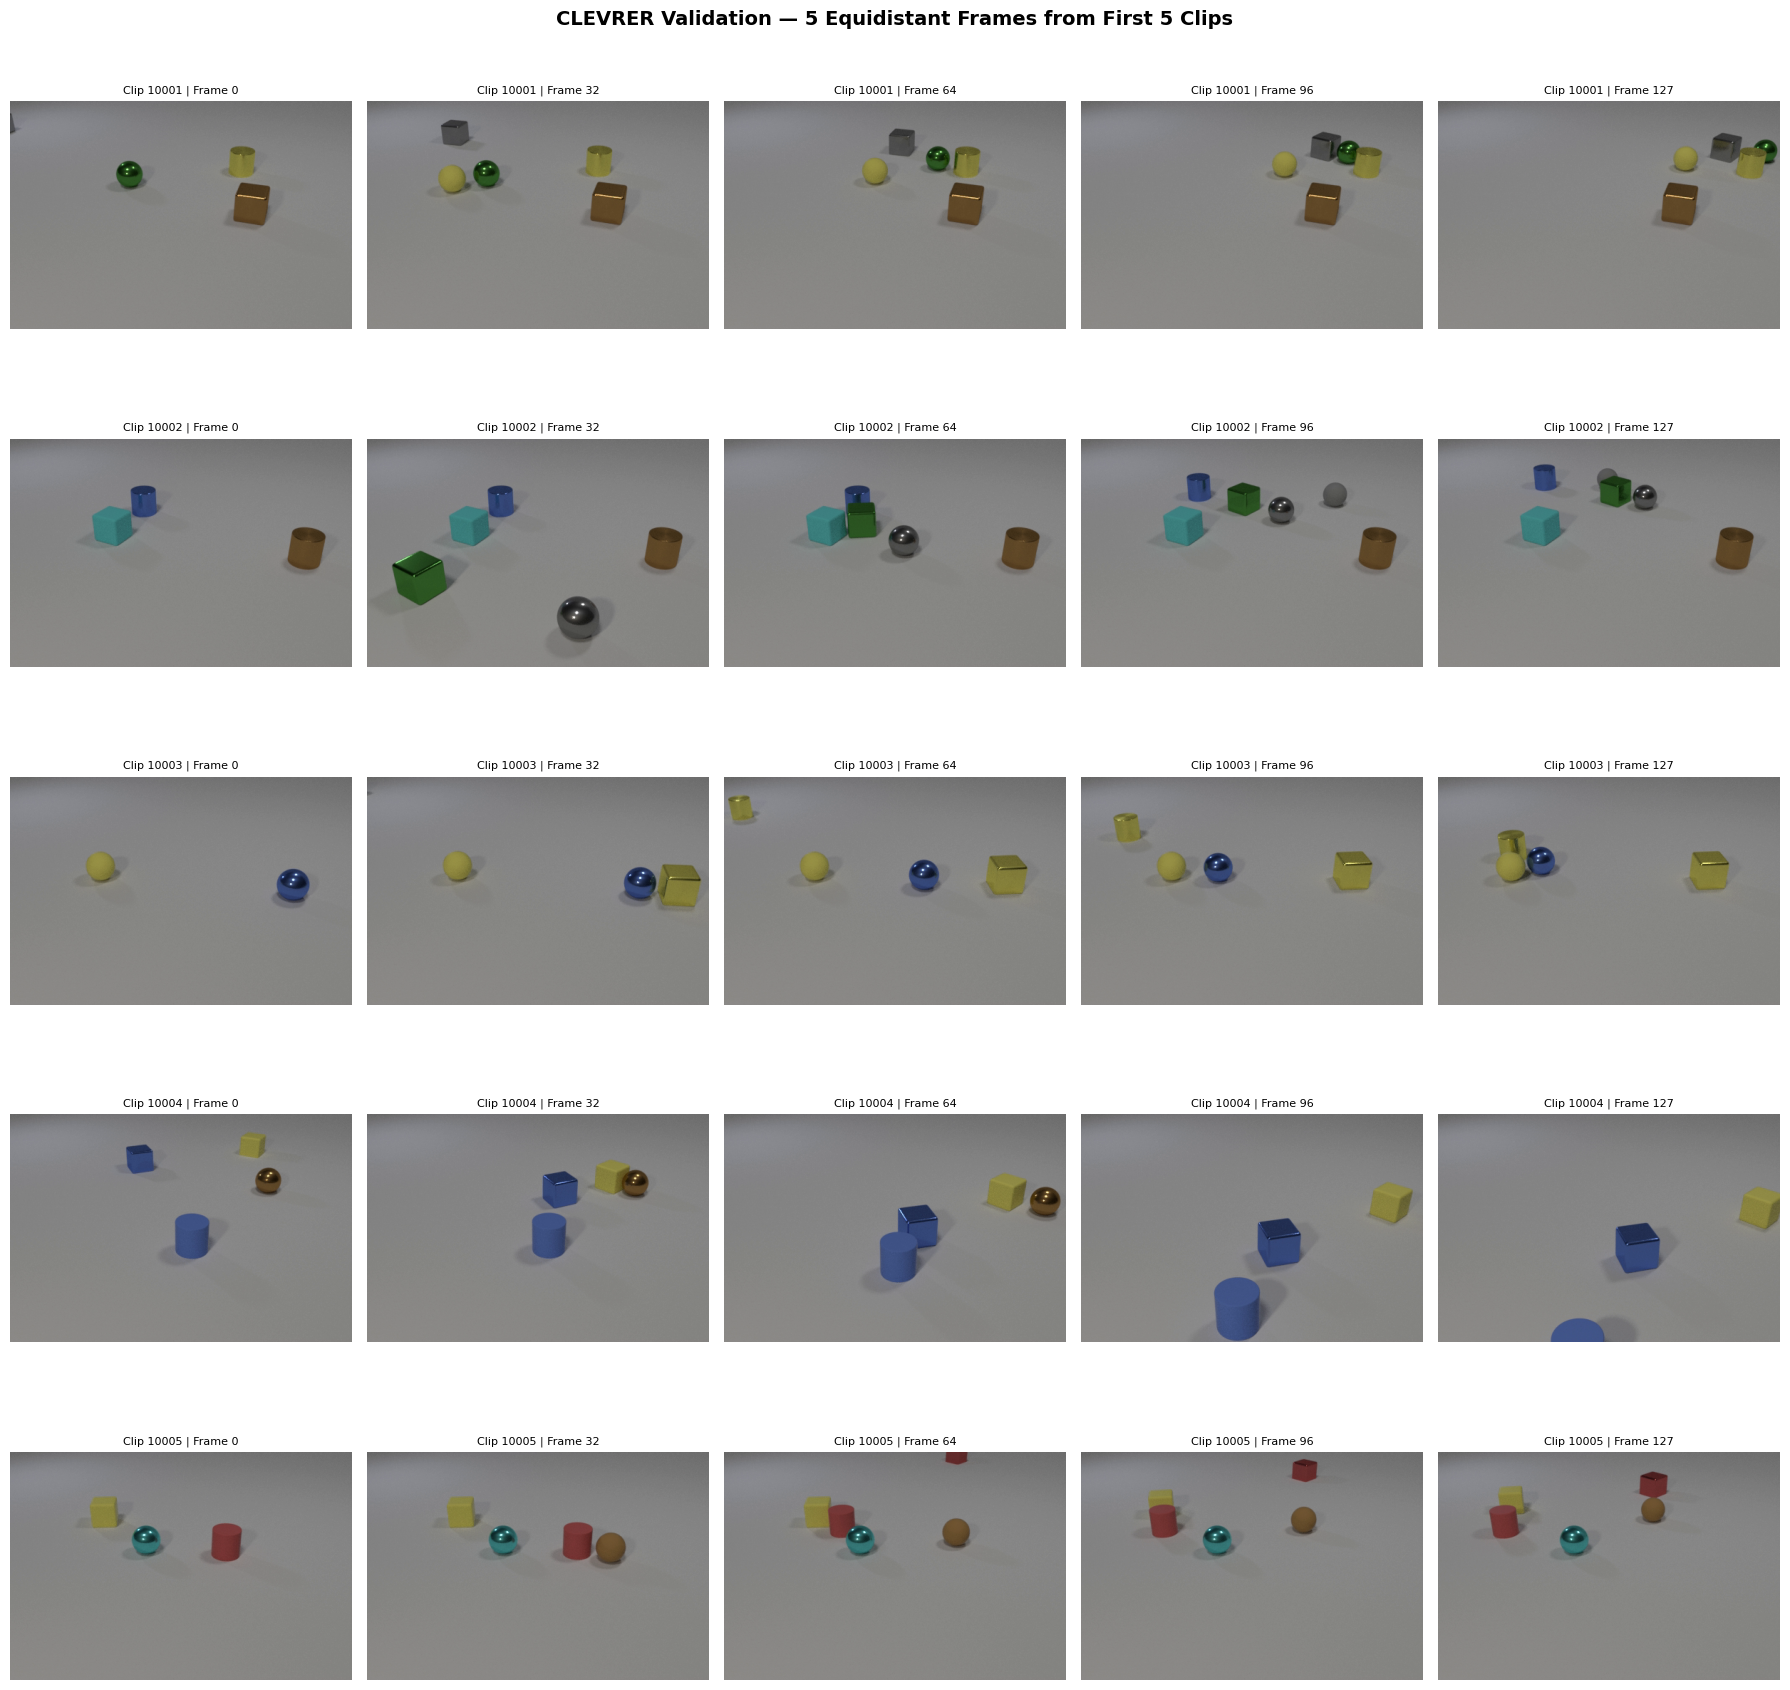

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/00_clip_equidistant_frames.jpg


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 5, figsize=(18, 18))
fig.suptitle('CLEVRER Validation — 5 Equidistant Frames from First 5 Clips', fontsize=14, fontweight='bold')

for i, vid_id in enumerate(SELECTED_IDS[:5]):
    clip_path = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")
    cap = cv2.VideoCapture(clip_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = [int(total_frames * j / 4) for j in range(4)] + [total_frames - 1] # 0, 25%, 50%, 75%, 100%


    for j, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        ax = axes[i][j]
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Clip {vid_id} | Frame {frame_idx}', fontsize=8)
        ax.axis('off')
    cap.release()

plt.tight_layout()
fig_path = os.path.join(BASE, 'figures/00_clip_equidistant_frames.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()  # prevent blocking
print(f'Saved -> {fig_path}')

---
## Cell 9 — Question Type Distribution (Report Figure)

Bar chart of question counts by type across all 'n' clips.
Saved to `figures/00_question_type_distribution.jpg`.

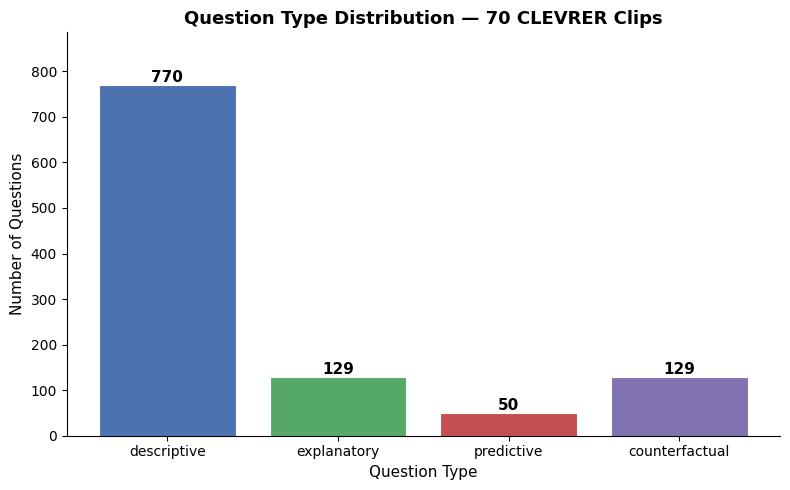

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/00_question_type_distribution.jpg


In [17]:
type_totals = {t: sum(r[t] for r in summary_rows) for t in Q_TYPES}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars   = ax.bar(type_totals.keys(), type_totals.values(),
                color=colors, edgecolor='white', linewidth=0.8)

# Annotate each bar with its count
for bar, val in zip(bars, type_totals.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title(f'Question Type Distribution — {NO_CLIPS} CLEVRER Clips', fontsize=13, fontweight='bold')
ax.set_xlabel('Question Type', fontsize=11)
ax.set_ylabel('Number of Questions', fontsize=11)
ax.set_ylim(0, max(type_totals.values()) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(BASE, 'figures/00_question_type_distribution.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()  # prevent blocking
print(f'Saved -> {fig_path}')

In [18]:
# ── Cell 9b — Answer Type Analysis per Question Type ─────────────────────────

# For each question type, analyze:
#   1. Does it come with choices or a direct answer?
#   2. If choices, how many options and how many correct?

from collections import Counter

Q_TYPES = ['descriptive', 'explanatory', 'predictive', 'counterfactual']

# Filter QA to our 'n' selected clips only
selected_set = set(SELECTED_IDS)
our_qa = [entry for entry in all_qa if entry['scene_index'] in selected_set]

for qt in Q_TYPES:
    print(f"\n{'─'*55}")
    print(f"  [{qt.upper()}]")
    print(f"{'─'*55}")

    # Collect all questions of this type
    qs = [q for entry in our_qa
            for q in entry.get('questions', [])
            if q.get('question_type') == qt]

    print(f"  Total questions : {len(qs)}")

    # Separate into direct-answer vs choices
    direct  = [q for q in qs if 'choices' not in q or len(q.get('choices', [])) == 0]
    choices = [q for q in qs if 'choices' in q and len(q.get('choices', [])) > 0]

    print(f"  No options (direct answer) : {len(direct)}")
    print(f"  Has options (choices)      : {len(choices)}")

    if direct:
        # Show distribution of direct answer values
        answer_vals = Counter(q.get('answer', 'N/A') for q in direct)
        print(f"\n  Direct answer values:")
        for val, count in sorted(answer_vals.items(), key=lambda x: -x[1]):
            print(f"    '{val}' : {count}x")

    if choices:
        # Number of options distribution
        n_options_counter  = Counter(len(q['choices']) for q in choices)
        # Number of correct answers distribution
        n_correct_counter  = Counter(
            sum(1 for c in q['choices'] if c.get('answer') == 'correct')
            for q in choices
        )

        print(f"\n  Options count distribution:")
        for n, count in sorted(n_options_counter.items()):
            print(f"    {n} options : {count} questions")

        print(f"\n  Correct answers distribution:")
        for n, count in sorted(n_correct_counter.items()):
            label = 'single-correct' if n == 1 else f'multi-correct ({n})'
            print(f"    {n} correct ({label}) : {count} questions")

        # Combined category breakdown
        print(f"\n  Combined category breakdown:")
        category_counter = Counter(
            f"{len(q['choices'])}-options + "
            f"{'single' if sum(1 for c in q['choices'] if c.get('answer')=='correct')==1 else 'multi'}"
            f"-correct"
            for q in choices
        )
        for cat, count in sorted(category_counter.items()):
            print(f"    {cat} : {count} questions")

print(f"\n{'─'*55}")
print("Analysis complete.")


───────────────────────────────────────────────────────
  [DESCRIPTIVE]
───────────────────────────────────────────────────────
  Total questions : 770
  No options (direct answer) : 770
  Has options (choices)      : 0

  Direct answer values:
    '1' : 85x
    'yes' : 76x
    '0' : 69x
    'metal' : 69x
    'no' : 64x
    '2' : 55x
    '3' : 55x
    'rubber' : 47x
    'cylinder' : 46x
    'sphere' : 41x
    'cube' : 31x
    'blue' : 19x
    'red' : 17x
    'green' : 16x
    '4' : 16x
    'gray' : 15x
    'yellow' : 13x
    'cyan' : 13x
    'brown' : 12x
    'purple' : 11x

───────────────────────────────────────────────────────
  [EXPLANATORY]
───────────────────────────────────────────────────────
  Total questions : 129
  No options (direct answer) : 0
  Has options (choices)      : 129

  Options count distribution:
    3 options : 55 questions
    4 options : 74 questions

  Correct answers distribution:
    0 correct (multi-correct (0)) : 23 questions
    1 correct (single-corr

---
## Cell 10 — Drive Space Check

In [19]:
total_bytes = sum(
    os.path.getsize(os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4"))
    for vid_id in SELECTED_IDS
    if os.path.exists(os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4"))
)

print(f'Clips on Drive  : {len(SELECTED_IDS)} files')
print(f'Total size      : {total_bytes / 1e6:.1f} MB')
print(f'Average per clip: {total_bytes / NO_CLIPS / 1e6:.1f} MB')
print('\nNotebook 00 complete. Proceed to Notebook 01 — SAM 2 Tracking.')

Clips on Drive  : 70 files
Total size      : 85.8 MB
Average per clip: 1.2 MB

Notebook 00 complete. Proceed to Notebook 01 — SAM 2 Tracking.


---

- Are the predictive questions about 'Mid-clip' or 'Post-clip' events?

In [20]:
# Print all predictive questions across our 10 clips with their answers
our_qa = [entry for entry in all_qa if entry['scene_index'] in set(SELECTED_IDS)]

for entry in our_qa:
    clip_id = entry['scene_index']
    pred_qs = [q for q in entry['questions'] if q.get('question_type') == 'predictive']
    if not pred_qs:
        continue
    print(f"\nClip {clip_id}:")
    for q in pred_qs:
        print(f"  Q: {q['question']}")
        for c in q.get('choices', []):
            correct = '✓' if c['answer'] == 'correct' else '✗'
            print(f"    [{correct}] {c['choice']}")


Clip 10001:
  Q: What will happen next?
    [✓] The rubber object collides with the gray object
    [✗] The rubber object collides with the brown object

Clip 10003:
  Q: What will happen next?
    [✗] The cube and the blue sphere collide
    [✓] The metal sphere and the cylinder collide

Clip 10005:
  Q: What will happen next?
    [✓] The brown object and the metal cube collide
    [✗] The red cube collides with the yellow object

Clip 10006:
  Q: Which event will happen next?
    [✓] The metal cube and the rubber cube collide
    [✗] The sphere and the cylinder collide

Clip 10007:
  Q: Which event will happen next?
    [✓] The gray cylinder and the blue cube collide
    [✗] The gray cylinder collides with the brown object

Clip 10008:
  Q: Which event will happen next?
    [✓] The metal cylinder and the purple sphere collide
    [✗] The gray object collides with the cube

Clip 10009:
  Q: Which event will happen next?
    [✗] The yellow sphere and the red sphere collide
    [✓] The

---
## Cell 11 — Download Annotation Files

In [21]:
# ── Cell 11 — Download Annotation Files ───────────────────────────────────────

# Annotation files contain per-clip object properties, motion trajectories,
# and collision events. We need these to find the optimal keyframe per clip.
# Strategy: same as clips -- download full zip to scratch, extract 'n', delete zip.

ANNOTATIONS_DIR = os.path.join(BASE, "data/annotations")
os.makedirs(ANNOTATIONS_DIR, exist_ok=True)

ANN_ZIP_URL   = "http://data.csail.mit.edu/clevrer/annotations/validation/annotation_validation.zip"
ANN_ZIP_LOCAL = "/content/annotation_validation.zip"

# Check how many annotations already on Drive
already_done_ann = [
    vid_id for vid_id in SELECTED_IDS
    if os.path.exists(os.path.join(ANNOTATIONS_DIR, f"annotation_{vid_id:05d}.json"))
]
print(f"Already on Drive : {len(already_done_ann)}/{NO_CLIPS}")
print(f"Still needed     : {NO_CLIPS - len(already_done_ann)}/{NO_CLIPS}")

if len(already_done_ann) == NO_CLIPS:
    print("All annotations already downloaded. Skipping.")
else:
    # Step 1 -- download zip to scratch
    print("\nStep 1: Downloading annotation zip to Colab scratch...")
    !wget -q --show-progress -O {ANN_ZIP_LOCAL} {ANN_ZIP_URL}

    # Step 2 -- extract only our 'n' annotation JSONs to Drive
    print("\nStep 2: Extracting annotations to Drive...")
    needed_ann = set(
        f"annotation_{vid_id:05d}.json" for vid_id in SELECTED_IDS
        if vid_id not in already_done_ann
    )

    with zipfile.ZipFile(ANN_ZIP_LOCAL, 'r') as zf:
        all_files = zf.namelist()
        for zip_entry in tqdm(all_files, desc="Scanning zip"):
            filename = os.path.basename(zip_entry)
            if filename in needed_ann:
                data     = zf.read(zip_entry)
                out_path = os.path.join(ANNOTATIONS_DIR, filename)
                with open(out_path, 'wb') as f:
                    f.write(data)
                needed_ann.discard(filename)
            if not needed_ann:
                break

    # Step 3 -- delete zip
    print("\nStep 3: Deleting annotation zip from scratch space...")
    os.remove(ANN_ZIP_LOCAL)
    print("Done. Zip deleted.")

    if needed_ann:
        print(f"WARNING: These annotations were not found: {needed_ann}")
    else:
        print(f"All {NO_CLIPS} annotation files extracted successfully.")

Already on Drive : 0/70
Still needed     : 70/70

Step 1: Downloading annotation zip to Colab scratch...
/content/annotation 100%[===================>]  74.75M  50.8MB/s    in 1.5s    

Step 2: Extracting annotations to Drive...


Scanning zip:  20%|█▉        | 987/5005 [00:00<00:02, 1561.45it/s]


Step 3: Deleting annotation zip from scratch space...
Done. Zip deleted.
All 70 annotation files extracted successfully.


---
## Cell 12 — Inspect Annotation Structure

In [22]:
# ── Cell 12 — Inspect Annotation File Structure ────────────────────────────────

# Load one annotation file and explore all fields, subfields, and sample values.
# Goal: understand the structure before building keyframe extraction logic on it.

import json

# Load first annotation file
sample_ann_path = os.path.join(
    ANNOTATIONS_DIR, f"annotation_{SELECTED_IDS[0]:05d}.json"
)
with open(sample_ann_path, 'r') as f:
    ann = json.load(f)

# ── Top level fields ───────────────────────────────────────────────────────────
print("TOP LEVEL FIELDS:")
print(f"  Type : {type(ann)}")
for key in ann.keys():
    val = ann[key]
    print(f"  '{key}' : {type(val).__name__} = {repr(val)[:80]}")

# ── object_property ───────────────────────────────────────────────────────────
print("\n" + "─"*60)
print("OBJECT_PROPERTY field:")
obj_props = ann.get('object_property', [])
print(f"  Number of objects : {len(obj_props)}")
if obj_props:
    print(f"  Keys in one object: {list(obj_props[0].keys())}")
    for obj in obj_props:
        print(f"    {obj}")

# ── motion_trajectory ─────────────────────────────────────────────────────────
print("\n" + "─"*60)
print("MOTION_TRAJECTORY field:")
traj = ann.get('motion_trajectory', [])
print(f"  Number of frames  : {len(traj)}")
if traj:
    print(f"  Keys in one frame : {list(traj[0].keys())}")
    print(f"\n  Sample frame (frame 0):")
    frame0 = traj[0]
    print(f"    frame_id : {frame0['frame_id']}")
    print(f"    objects  : {len(frame0['objects'])} objects")
    if frame0['objects']:
        print(f"    Keys in one object entry: {list(frame0['objects'][0].keys())}")
        print(f"    Sample object entry:")
        for key, val in frame0['objects'][0].items():
            print(f"      '{key}' : {repr(val)[:80]}")

# ── collision ─────────────────────────────────────────────────────────────────
print("\n" + "─"*60)
print("COLLISION field:")
collisions = ann.get('collision', [])
print(f"  Number of collisions : {len(collisions)}")
if collisions:
    print(f"  Keys in one collision: {list(collisions[0].keys())}")
    print(f"\n  All collisions:")
    for c in collisions:
        print(f"    {c}")

# ── Check for enter/exit events ───────────────────────────────────────────────
print("\n" + "─"*60)
print("CHECKING FOR ENTER/EXIT EVENTS:")
print("  Top level keys:", list(ann.keys()))
print("  (Enter/exit may be inside motion_trajectory or a separate field)")

# Check inside_camera_view changes as proxy for enter/exit
print("\n  Checking 'inside_camera_view' across frames for object 0:")
transitions = []
prev = None
for frame in traj:
    for obj in frame['objects']:
        if obj['object_id'] == 0:
            curr = obj.get('inside_camera_view', None)
            if curr != prev:
                transitions.append((frame['frame_id'], curr))
                prev = curr
print(f"  Object 0 camera view transitions: {transitions}")

TOP LEVEL FIELDS:
  Type : <class 'dict'>
  'scene_index' : int = 10001
  'video_filename' : str = 'video_10001.mp4'
  'object_property' : list = [{'object_id': 0, 'color': 'yellow', 'material': 'rubber', 'shape': 'sphere'}, {
  'motion_trajectory' : list = [{'frame_id': 0, 'objects': [{'object_id': 0, 'location': [0.1231, -3.6234, 0.2]
  'collision' : list = [{'object_ids': [0, 1], 'frame_id': 34, 'location': [-0.8184, -0.9688, 0.2008]},

────────────────────────────────────────────────────────────
OBJECT_PROPERTY field:
  Number of objects : 5
  Keys in one object: ['object_id', 'color', 'material', 'shape']
    {'object_id': 0, 'color': 'yellow', 'material': 'rubber', 'shape': 'sphere'}
    {'object_id': 1, 'color': 'green', 'material': 'metal', 'shape': 'sphere'}
    {'object_id': 2, 'color': 'yellow', 'material': 'metal', 'shape': 'cylinder'}
    {'object_id': 3, 'color': 'gray', 'material': 'metal', 'shape': 'cube'}
    {'object_id': 4, 'color': 'brown', 'material': 'metal', 'sha

---
## Cell 14 -- Extract and Save Keyframes as JPEGs


Saved          : 70
Skipped        : 0 (already on Drive)
Failed         : 0

Keyframe index saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/data/keyframe_index.json
Frame numbers  : {10001: 127, 10002: 127, 10003: 127, 10004: 127, 10005: 127, 10006: 127, 10007: 127, 10008: 127, 10009: 127, 10010: 127, 10011: 127, 10012: 127, 10013: 127, 10014: 127, 10015: 127, 10016: 127, 10017: 127, 10018: 127, 10019: 127, 10020: 127, 10021: 127, 10022: 127, 10023: 127, 10024: 127, 10025: 127, 10026: 127, 10027: 127, 10028: 127, 10029: 127, 10030: 127, 10031: 127, 10032: 127, 10033: 127, 10034: 127, 10035: 127, 10036: 127, 10037: 127, 10038: 127, 10039: 127, 10040: 127, 10041: 127, 10042: 127, 10043: 127, 10044: 127, 10045: 127, 10046: 127, 10047: 127, 10048: 127, 10049: 127, 10050: 127, 10051: 127, 10052: 127, 10053: 127, 10054: 127, 10055: 127, 10056: 127, 10057: 127, 10058: 127, 10059: 127, 10060: 127, 10061: 127, 10062: 127, 10063: 127, 10064: 127, 10065: 12

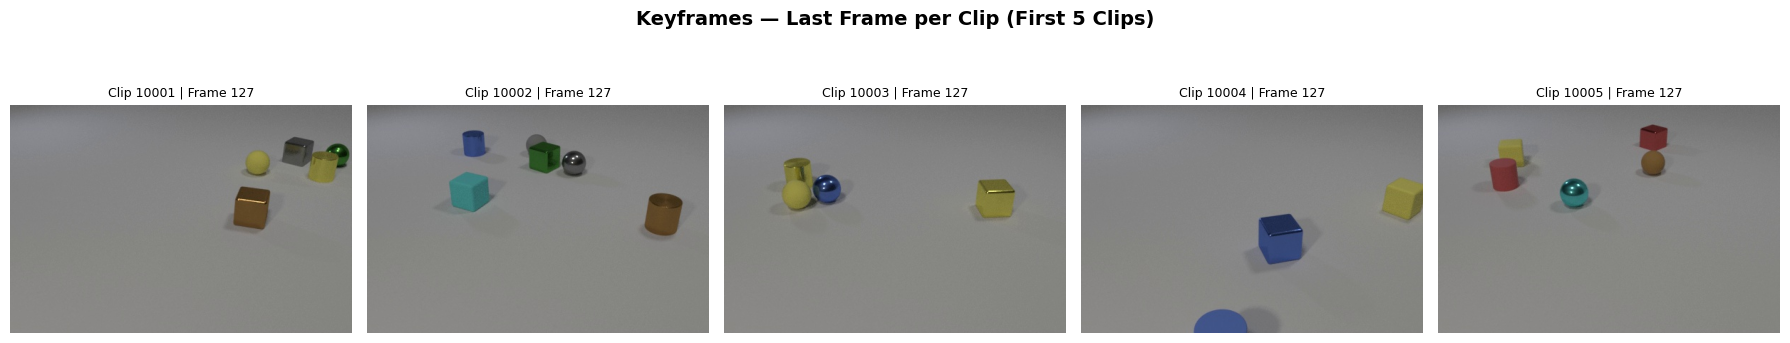


Keyframe grid saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/00_keyframes.jpg

Notebook 00 complete. Proceed to Notebook 01 — LLaVA Baseline.


In [26]:
# ── Cell 14 — Extract and Save Last Frames as JPEGs ───────────────────────────

# For each clip, extract the last frame from the .mp4 and save to Drive.
# We use the last frame for all question types because:
#   - Descriptive  : all events complete, object attributes still visible
#   - Explanatory  : full causal chain complete, all collisions have occurred
#   - Predictive   : model predicts what happens after this exact moment
#   - Counterfactual: full observed reality serves as counterfactual baseline
#
# The keyframe index is saved to Drive for use in all later notebooks.

import cv2
import os
import json
import matplotlib.pyplot as plt

KEYFRAMES_DIR = os.path.join(BASE, "data/keyframes")
os.makedirs(KEYFRAMES_DIR, exist_ok=True)

keyframe_index = {}  # vid_id -> actual last frame number
saved   = []
skipped = []
failed  = []

for vid_id in SELECTED_IDS:
    out_path  = os.path.join(KEYFRAMES_DIR, f"frame_{vid_id:05d}.jpg")
    clip_path = os.path.join(BASE, "data/clips", f"video_{vid_id:05d}.mp4")

    cap          = cv2.VideoCapture(clip_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    key_frame    = total_frames - 1

    # Store actual frame number used
    keyframe_index[vid_id] = key_frame

    # Skip extraction if already saved -- still update index
    if os.path.exists(out_path):
        cap.release()
        skipped.append(vid_id)
        continue

    # Seek to last frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, key_frame)
    ret, frame = cap.read()

    # Fallback to second-to-last if last frame unreadable
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, key_frame - 1)
        ret, frame = cap.read()
        keyframe_index[vid_id] = key_frame - 1

    cap.release()

    if ret:
        cv2.imwrite(out_path, frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved.append(vid_id)
    else:
        failed.append(vid_id)

# Save keyframe index to Drive -- all later notebooks load this
kf_path = os.path.join(BASE, "data/keyframe_index.json")
with open(kf_path, 'w') as f:
    json.dump(keyframe_index, f)

print(f"Saved          : {len(saved)}")
print(f"Skipped        : {len(skipped)} (already on Drive)")
print(f"Failed         : {len(failed)}")
print(f"\nKeyframe index saved -> {kf_path}")
print(f"Frame numbers  : {keyframe_index}")

# ── Visual grid of first 5 keyframes (report figure) ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Keyframes — Last Frame per Clip (First 5 Clips)', fontsize=14, fontweight='bold')

for i, vid_id in enumerate(SELECTED_IDS[:5]):
    out_path  = os.path.join(KEYFRAMES_DIR, f"frame_{vid_id:05d}.jpg")
    key_frame = keyframe_index.get(vid_id, 0)
    img       = cv2.imread(out_path)
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"Clip {vid_id} | Frame {key_frame}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
fig_path = os.path.join(BASE, 'figures/00_keyframes.jpg')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"\nKeyframe grid saved -> {fig_path}")
print("\nNotebook 00 complete. Proceed to Notebook 01 — LLaVA Baseline.")

---